# Import Data

In [8]:
%pip install seaborn

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import seaborn as sns
from IPython.display import display, clear_output
warnings.filterwarnings('ignore')
import re
import string
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

print("TensorFlow version:", tf.__version__)

Note: you may need to restart the kernel to use updated packages.
TensorFlow version: 2.20.0


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\T460s\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Data Loading & Pengecekan

In [9]:
train_path = 'Constraint_Train.csv'
val_path = 'Constraint_Val.csv'
test_path = 'Constraint_Test.csv'


try:
    df_train = pd.read_csv(train_path)
    df_val = pd.read_csv(val_path)
    df_test = pd.read_csv(test_path)
    print("Data berhasil dimuat!")
    print("Jumlah Data Latih:", len(df_train))
    print("Jumlah Data Validasi:", len(df_val))
    print("Jumlah Data Uji:", len(df_test))


    display(df_train.head(3))
except FileNotFoundError:
    print("File CSV tidak ditemukan! Pastikan Anda sudah mengunggah file ke Google Colab.")

Data berhasil dimuat!
Jumlah Data Latih: 6420
Jumlah Data Validasi: 2140
Jumlah Data Uji: 2140


,id,tweet,label
0,1,The CDC currently reports 99031 deaths. In gen...,real
1,2,States reported 1121 deaths a small rise from ...,real
2,3,Politically Correct Woman (Almost) Uses Pandem...,fake


# Data Preprocessing

In [10]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # hapus URL
    text = re.sub(r'@\w+|#\w+', '', text)            # hapus mention & hashtag
    text = re.sub(r'[^a-z\s]', '', text)             # hapus angka & tanda baca
    text = re.sub(r'\s+', ' ', text).strip()         # normalisasi spasi
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]  # hapus stopwords
    return ' '.join(tokens)

X_train_text = df_train['tweet'].astype(str).apply(clean_text)
y_train_label = df_train['label']

X_val_text = df_val['tweet'].astype(str).apply(clean_text)
y_val_label = df_val['label']

# Membuat Custom Attention Layer

In [11]:
@tf.keras.utils.register_keras_serializable()
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight',
                                 shape=(input_shape[-1], 1),
                                 initializer='random_normal',
                                 trainable=True)
        self.b = self.add_weight(name='attention_bias',
                                 shape=(input_shape[1], 1),
                                 initializer='zeros',
                                 trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)


        output = x * a

        return tf.keras.backend.sum(output, axis=1), a

    def get_config(self):
        return super(AttentionLayer, self).get_config()

# Membangun Model Deep Learning

In [12]:
EMBEDDING_DIM = 128

MAX_LENGTH = 100
VOCAB_SIZE = 10000

inputs = Input(shape=(MAX_LENGTH,), name='input_text')

x = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, name='embedding')(inputs)

x = Bidirectional(LSTM(64, return_sequences=True), name='bilstm')(x)

context_vector, attention_weights = AttentionLayer(name='attention')(x)

x = Dense(64, activation='relu')(context_vector)
x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid', name='output')(x)

model = Model(inputs=inputs, outputs=outputs, name='Hoax_Detector_XAI')
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', 'mae'])

model.summary()

inference_model = Model(inputs=model.input, outputs=[model.output, attention_weights])

Model: "Hoax_Detector_XAI"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_text (InputLayer)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ [(None, 128), (None,   │           228 │
│                                 │ 100, 1)]               │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,365 (5.29 MB)

 Trainable params: 1,387,365 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

# Membangun Custom Callback

In [13]:
class CustomLoggingCallback(tf.keras.callbacks.Callback):
    def __init__(self, target_accuracy=0.85, max_mae=0.02):
        super().__init__()
        self.target_accuracy = target_accuracy
        self.max_mae = max_mae

    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get('accuracy')
        mae = logs.get('mae')
        val_acc = logs.get('val_accuracy')
        val_mae = logs.get('val_mae')

        print(f"\n[Epoch {epoch+1} Selesai] Loss: {logs.get('loss'):.4f} | Akurasi: {acc*100:.2f}% | MAE: {mae:.4f} | Val Loss: {logs.get('val_loss'):.4f} | Val Akurasi: {val_acc*100:.2f}% | Val MAE: {val_mae:.4f}")

        if acc is not None and mae is not None:
            if acc >= self.target_accuracy and mae <= self.max_mae:
                print(f"\n[INFO] Target Pelatihan Tercapai: Akurasi Latih >= {self.target_accuracy*100}% dan MAE Latih <= {self.max_mae}!")
                print("Pelatihan dihentikan secara otomatis.")
                self.model.stop_training = True

my_callback = CustomLoggingCallback(target_accuracy=0.85, max_mae=0.02)

# Melakukan Pelatihan Model

In [16]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<unk>")
tokenizer.fit_on_texts(X_train_text)  # ✅ pakai X_train_text yang sudah clean_text()

import json
from tensorflow.keras.preprocessing.text import Tokenizer

# 1. Definisikan variabel pendukung secara manual
VOCAB_SIZE = 10000

# 2. Ambil data teks dari data training secara otomatis (Mencari kolom teks yang tersedia)
# Kode ini akan memeriksa semua kolom dan mengambil kolom pertama yang berisi teks panjang
text_column = None
for col in df_train.columns:
    # Cari nama kolom yang mengandung kata 'text', 'title', 'content', 'berita', atau 'statement'
    if any(keyword in col.lower() for keyword in ['text', 'title', 'content', 'berita', 'statement', 'tweet', 'judul', 'isi']):
        text_column = col
        break

# Jika tidak ketemu juga berdasarkan nama, ambil kolom pertama yang tipe datanya objek/string
if not text_column:
    text_column = df_train.select_dtypes(include=['object']).columns[0]

print(f"-> Menggunakan kolom teks dari dataset: '{text_column}'")
X_train_text = df_train[text_column].astype(str).tolist()

# 3. Buat dan latih objek Tokenizer asli
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<unk>")
tokenizer.fit_on_texts(X_train_text)

# 4. Export menjadi file tokenizer.json
tokenizer_json = tokenizer.to_json()
with open('tokenizer.json', 'w', encoding='utf-8') as f:
    f.write(json.dumps(tokenizer_json, ensure_ascii=False))

print("✅ SUKSES! File tokenizer.json berhasil dibuat!")


X_train_sequences = tokenizer.texts_to_sequences(X_train_text)  # ✅ sudah clean
X_val_sequences = tokenizer.texts_to_sequences(X_val_text)      # ✅ sudah clean

X_train = pad_sequences(X_train_sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_val = pad_sequences(X_val_sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(df_train['label'])
y_val = label_encoder.transform(df_val['label'])

EPOCHS = 20
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[my_callback]
)

-> Menggunakan kolom teks dari dataset: 'tweet'
✅ SUKSES! File tokenizer.json berhasil dibuat!
Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.6362 - loss: 0.6113 - mae: 0.4345
[Epoch 1 Selesai] Loss: 0.4944 | Akurasi: 75.47% | MAE: 0.3341 | Val Loss: 0.8803 | Val Akurasi: 60.75% | Val MAE: 0.3864
101/101 ━━━━━━━━━━━━━━━━━━━━ 35s 229ms/step - accuracy: 0.7547 - loss: 0.4944 - mae: 0.3341 - val_accuracy: 0.6075 - val_loss: 0.8803 - val_mae: 0.3864
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9040 - loss: 0.2782 - mae: 0.1604
[Epoch 2 Selesai] Loss: 0.2660 | Akurasi: 90.56% | MAE: 0.1551 | Val Loss: 0.7774 | Val Akurasi: 82.34% | Val MAE: 0.2890
101/101 ━━━━━━━━━━━━━━━━━━━━ 17s 164ms/step - accuracy: 0.9056 - loss: 0.2660 - mae: 0.1551 - val_accuracy: 0.8234 - val_loss: 0.7774 - val_mae: 0.2890
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.9447 - loss: 0.1662 - mae: 0.0971
[Epoch 3 Selesai] Loss: 0.1562 | Akurasi: 94.55% | 

# Evaluasi dan Simpan Model

In [8]:
eval_train = model.evaluate(X_train, y_train, verbose=0)
print(f"Hasil Evaluasi Data Latih (Train) - Loss: {eval_train[0]:.4f}, Accuracy: {eval_train[1]*100:.2f}%, MAE: {eval_train[2]:.4f}")

print("-" * 50)

eval_val = model.evaluate(X_val, y_val, verbose=0)
loss = eval_val[0]
accuracy = eval_val[1]
mae = eval_val[2]
print(f"Hasil Evaluasi Data Validasi (Val) - Loss: {loss:.4f}, Accuracy: {accuracy*100:.2f}%, MAE: {mae:.4f}")

model.save('hoax_detector_xai.keras')
print("Model berhasil disimpan dalam format 'hoax_detector_xai.keras'")

Hasil Evaluasi Data Latih (Train) - Loss: 0.0232, Accuracy: 99.53%, MAE: 0.0121
--------------------------------------------------
Hasil Evaluasi Data Validasi (Val) - Loss: 0.3224, Accuracy: 91.03%, MAE: 0.0962
Model berhasil disimpan dalam format 'hoax_detector_xai.keras'


# Pipeline Inferensi XAI

--------------------------------------------------
Teks Input: 'BREAKING NEWS: Covid-19 vaccine contains 5G tracking microchips funded by billionaires! Share this before it gets deleted.'
Prediksi  : Fake
Keyakinan : 99.78%
--------------------------------------------------
📌 Top 5 kata yang paling mempengaruhi prediksi:
  1. 'gets' — bobot attention: 0.0315  ██████
  2. 'deleted' — bobot attention: 0.0290  █████
  3. 'share' — bobot attention: 0.0260  █████
  4. '<unk>' — bobot attention: 0.0239  ████
  5. 'tracking' — bobot attention: 0.0219  ████

💡 Interpretasi: Model memprediksi teks ini sebagai 'Fake' dengan keyakinan 99.8%, terutama dipengaruhi oleh kata 'gets', 'deleted', dan 'share'.
--------------------------------------------------
--> [INFO] Menggambar Heatmap untuk 13 kata...


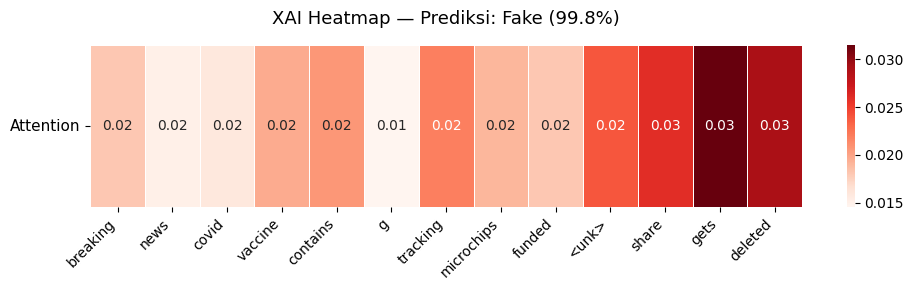



--------------------------------------------------
Teks Input: 'How a healthy 16-year-old boy lost his life to #COVID19 in just 12 days.'
Prediksi  : Real
Keyakinan : 99.32%
--------------------------------------------------
📌 Top 5 kata yang paling mempengaruhi prediksi:
  1. 'days' — bobot attention: 0.0097  █
  2. 'lost' — bobot attention: 0.0094  █
  3. 'life' — bobot attention: 0.0093  █
  4. 'boy' — bobot attention: 0.0086  █
  5. 'yearold' — bobot attention: 0.0084  █

💡 Interpretasi: Model memprediksi teks ini sebagai 'Real' dengan keyakinan 99.3%, terutama dipengaruhi oleh kata 'days', 'lost', dan 'life'.
--------------------------------------------------
--> [INFO] Menggambar Heatmap untuk 6 kata...


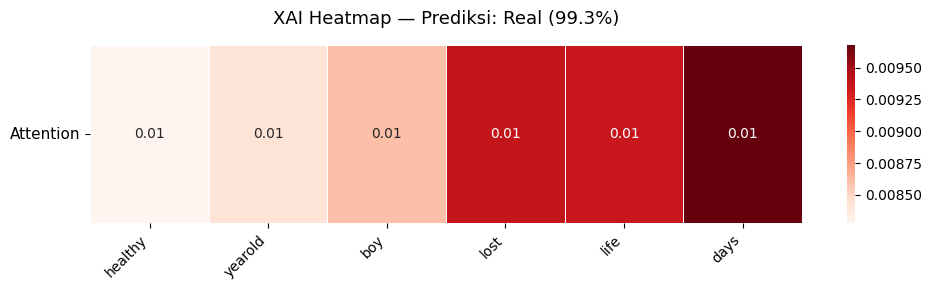

In [9]:
def predict_with_explanation(text):
    cleaned = clean_text(text)                          # ✅ bersihkan dulu
    seq = tokenizer.texts_to_sequences([cleaned])       # ✅ baru tokenize
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

    prediction, att_weights = inference_model.predict(padded, verbose=0)

    conf = prediction[0][0]
    is_real = conf > 0.5
    label_pred = "Real" if is_real else "Fake"
    confidence = conf if is_real else (1 - conf)

    print("-" * 50)
    print(f"Teks Input: '{text}'")
    print(f"Prediksi  : {label_pred}")
    print(f"Keyakinan : {confidence * 100:.2f}%")
    print("-" * 50)

    # Deklarasi word_indices SEBELUM digunakan
    word_indices = seq[0]

    if len(word_indices) > 0:
        words = [tokenizer.index_word.get(i, '<OOV>') for i in word_indices]
        w_att = att_weights[0][:len(words)].flatten()

        # --- XAI: Top kata berpengaruh ---
        word_weight_pairs = sorted(zip(words, w_att), key=lambda x: x[1], reverse=True)
        top_n = 5
        print(f"📌 Top {top_n} kata yang paling mempengaruhi prediksi:")
        for rank, (word, weight) in enumerate(word_weight_pairs[:top_n], 1):
            bar = '█' * int(weight * 200)
            print(f"  {rank}. '{word}' — bobot attention: {weight:.4f}  {bar}")

        print()
        print(f"💡 Interpretasi: Model memprediksi teks ini sebagai '{label_pred}' "
              f"dengan keyakinan {confidence*100:.1f}%, terutama dipengaruhi oleh "
              f"kata '{word_weight_pairs[0][0]}', '{word_weight_pairs[1][0]}', "
              f"dan '{word_weight_pairs[2][0]}'.")
        print("-" * 50)

        # --- XAI: Heatmap Attention ---
        print(f"--> [INFO] Menggambar Heatmap untuk {len(words)} kata...")

        plt.close('all')
        fig, ax = plt.subplots(figsize=(max(10, len(words) * 0.6), 3))

        sns.heatmap(
            [w_att],
            xticklabels=words,
            yticklabels=['Attention'],
            cmap='Reds',
            cbar=True,
            annot=True,
            fmt='.2f',
            linewidths=0.5,
            ax=ax
        )

        ax.set_title(
            f'XAI Heatmap — Prediksi: {label_pred} ({confidence*100:.1f}%)',
            pad=15, fontsize=13
        )
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(fontsize=11, rotation=0)
        plt.tight_layout()
        plt.show()

    else:
        print("Teks terlalu pendek atau berisi kata-kata yang tidak ada di vocabulary.")


teks_hoaks = "BREAKING NEWS: Covid-19 vaccine contains 5G tracking microchips funded by billionaires! Share this before it gets deleted."
predict_with_explanation(teks_hoaks)

print("\n")

teks_asli = "How a healthy 16-year-old boy lost his life to #COVID19 in just 12 days."
predict_with_explanation(teks_asli)